In [16]:
import numpy as np                              # Numerical operations
import pandas as pd                             # Data manipulation
import matplotlib.pyplot as plt                 # Plotting
import seaborn as sns                           # Statistical visualizations

from sklearn.preprocessing import PolynomialFeatures  # Transforms x -> [1, x, x², x³, ...]
from sklearn.linear_model import LinearRegression      # Linear regression model
from sklearn.pipeline import Pipeline                  # Chain preprocessing + model together
from sklearn.model_selection import train_test_split, cross_val_score  # Data splitting & CV
from sklearn.metrics import mean_squared_error, r2_score               # Evaluation metrics

np.random.seed(42)  # Reproducibility

In [17]:
from pathlib import Path

# Try common notebook/project locations for data.csv
candidates = [Path("data.csv"), Path("../data/data.csv"), Path("data/data.csv")] # Check current, parent, and data subdirectory
data_path = next((p for p in candidates if p.exists()), None)# Find the first existing path or return None

if data_path is None:
	print("Warning: data.csv not found. Using a fallback sample dataset.")# Create a simple dataset if data.csv is missing

	# np.linspace(start, stop, num):
	#   start = 0    → first value of the sequence
	#   stop  = 10   → last value of the sequence
	#   num   = 100  → number of evenly spaced points between start and stop
	#   X_min = read_data["X"].min()   # جایگزین 0
    #   X_max = read_data["X"].max()   # جایگزین 10
    #    n  = len(read_data)         # جایگزین 100
	#
	# pd.DataFrame({...}) → creates a table (DataFrame) from a dictionary
	#   "X"              → column name in the table
	#   read_data        → variable that stores the resulting DataFrame

	X_min = read_data["X"].min()   # جایگزین 0
	X_max = read_data["X"].max()   # جایگزین 10
	n = len(read_data)             # جایگزین 100
	X_values = np.linspace(X_min, X_max, n)  # 100 evenly spaced numbers
	read_data = pd.DataFrame({"X": X_values})  # DataFrame with one column "X"
else:
	read_data = pd.read_csv(data_path)  # Load dataset

# Ensure an X column exists
if "X" not in read_data.columns: # If 'X' is missing, try to find a numeric column to use as X
	numeric_cols = read_data.select_dtypes(include=[np.number]).columns 	# Get numeric columns
	if len(numeric_cols) > 0:
		read_data["X"] = read_data[numeric_cols[0]]
		print(f"Column 'X' not found. Using '{numeric_cols[0]}' as X.")
	else:
		read_data["X"] = np.arange(len(read_data))
		print(f"No numeric column found. Generated index-based X with values: {read_data['X'].head().tolist()}.")

X = read_data["X"].values.reshape(-1, 1)  # Features
print(read_data.head())

Column 'X' not found. Using 'x' as X.
          x          y         X
0 -0.752759   2.614514 -0.752759
1  2.704286  18.304580  2.704286
2  1.391964   5.561354  1.391964
3  0.591951  -3.508589  0.591951
4 -2.063888   1.204914 -2.063888


# Polynomial Degree Selection — درجه بهینه رگرسیون

**Goal:** Determine which polynomial degree fits the data best **without overfitting**.

**Six steps:**

| # | Step | What happens |
|---|------|-------------|
| 0 | Prepare data | Extract feature `X` and target `y` into NumPy arrays |
| 1 | Train / Test split | 80 % training — 20 % held-out test set |
| 2 | Pipeline + CV loop | For each degree 1–8: build model, run 5-fold cross-validation |
| 3 | Select best degree | Pick degree with the lowest CV-RMSE |
| 4 | Visualise | Plot RMSE curves so the trend and best point are visible |
| 5 | Report | Print best degree and both RMSE values |

---


---
## Abbreviations Used in This Notebook

| Short | Full Name | What it means in plain words |
|-------|-----------|------------------------------|
| **RMSE** | **Root Mean Squared Error** | Square root of the average of all squared prediction errors. Same unit as `y`. Lower = better. |
| **MSE** | **Mean Squared Error** | Average of all squared differences between predicted and actual values. RMSE = √MSE. |
| **MAE** | **Mean Absolute Error** | Average of absolute differences between predicted and actual values (not used here, but related). |
| **CV** | **Cross-Validation** | Technique to estimate model performance by splitting training data into folds repeatedly. |
| **CV-RMSE** | **Cross-Validation Root Mean Squared Error** | RMSE averaged across all CV folds — used to *select* the best model. |
| **VAL** | **Validation** | The fold used for measuring error in one CV round (never trained on in that round). |
| **R²** | **R-squared / Coefficient of Determination** | Proportion of variance in `y` explained by the model. Range: −∞ to 1. Higher = better. |
| **neg_MSE** | **Negative Mean Squared Error** | MSE multiplied by −1. sklearn uses this because its scoring convention is "higher = better". |
| **sklearn** | **scikit-learn** | Python machine learning library providing `Pipeline`, `LinearRegression`, `cross_val_score`, etc. |
| **API** | **Application Programming Interface** | The set of functions/classes a library exposes for you to use. |

---

### RMSE formula step by step

```
Given n data points, each with a true value yᵢ and a predicted value ŷᵢ:

  Error per point   eᵢ  =  yᵢ − ŷᵢ

  Squared error         =  eᵢ²          (makes all errors positive, penalises large errors more)

  MSE  (Mean Squared Error)   =  (1/n) · Σ eᵢ²     ← average of squared errors

  RMSE (Root Mean Squared Error) =  √MSE            ← back to original unit of y
```

**Why square and then take the root instead of just averaging errors?**
- Raw errors can be positive or negative and would cancel out (mean ≈ 0)
- Squaring makes all errors positive and penalises large errors more heavily
- Taking the square root at the end converts back to the same unit as `y`

---

### R² formula

```
  R²  =  1  −  ( Σ(yᵢ − ŷᵢ)² ) / ( Σ(yᵢ − ȳ)² )
              ↑ model's errors       ↑ variance of y (baseline: just predicting the mean)

  R² = 1.0  → model explains all variance (perfect fit)
  R² = 0.0  → model is no better than predicting the mean of y
  R² < 0    → model is worse than predicting the mean
```


In [18]:
# test_size=0.2  → 20% of rows go to the test set, the remaining 80% to training
# random_state=42 → fixes the random seed so the split is identical every time you run
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Training samples : {len(X_train)}")   # 80% of total
print(f"Test samples     : {len(X_test)}")     # 20% of total


Training samples : 80
Test samples     : 20


---
## Step 1 — Train / Test Split

We divide the full dataset into **two non-overlapping parts**:

| Variable | Size | Role |
|----------|------|------|
| `X_train`, `y_train` | **80 %** | Used to train models and run cross-validation |
| `X_test`, `y_test` | **20 %** | Held out — only touched once at the very end |

> **Why do we need a test set at all?**  
> If we measured RMSE on the same data the model trained on, the error would always look small — the model has already memorised those points.  
> The test set provides a realistic estimate of performance on **new, unseen data**.

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `test_size` | `0.2` | 20 % goes to test, 80 % to training |
| `random_state` | `42` | Fixed random seed → identical split on every run |


In [15]:
import warnings
warnings.filterwarnings("ignore")   # sklearn prints numerical warnings for high-degree polynomials; safe to suppress here

# safety check: without a target column 'y' there is nothing to predict
# raising an error here gives a clear message instead of a cryptic crash later
if "y" not in read_data.columns:
    raise ValueError("Column 'y' not found in dataset. Cannot perform regression.")

# reshape(-1, 1): sklearn always needs a 2-D feature matrix (rows=samples, cols=features)
# .values converts the pandas Series to a NumPy array
# -1 means "infer this dimension" → shape (n,) becomes (n, 1)
X_reg = read_data["X"].values.reshape(-1, 1)   # feature matrix — shape (n_samples, 1)

# target stays 1-D: one number per sample, no reshaping needed
y_reg = read_data["y"].values                   # target vector  — shape (n_samples,)

print(f"X_reg shape : {X_reg.shape}")   # should be (n, 1)
print(f"y_reg shape : {y_reg.shape}")   # should be (n,)


X_reg shape : (100, 1)
y_reg shape : (100,)


---
## Step 2 — Pipeline & Cross-Validation Loop

---

### What is a Pipeline?

A `Pipeline` is a container that **chains multiple steps into one single object**.  
Instead of calling each step manually, the pipeline does them automatically — always in the same fixed order.

In our case the pipeline has exactly two steps:

```
Raw data   →   [ PolynomialFeatures ]   →   [ LinearRegression ]   →   Prediction
   x                [1, x, x², x³]              y = w₀+w₁x+w₂x²+…
```

| Step | Name in code | What it does |
|------|-------------|-------------|
| 1 | `"poly"` | `PolynomialFeatures(degree=d)` — expands one column `[x]` into `[1, x, x², …, xᵈ]` |
| 2 | `"linreg"` | `LinearRegression()` — fits weights `w₀, w₁, …, wₐ` on the expanded columns |

`include_bias=True` → adds the constant column of ones (`1`) so the model can learn an intercept `w₀`.

---

### What is Cross-Validation?

Cross-validation (CV) is a technique to **estimate how well a model generalises** to new data — using only the training set, without touching the test set.

#### What does "generalises" mean?

**Generalisation** = the ability of a trained model to make accurate predictions on **data it has never seen before**.

```
                    ┌─────────────────────────────────────────┐
                    │           Two extreme cases              │
                    ├──────────────────┬──────────────────────┤
                    │   Overfitting    │    Good generalisation│
                    │   (does NOT      │    (DOES generalise)  │
                    │    generalise)   │                       │
                    ├──────────────────┼──────────────────────┤
                    │ Train RMSE: 0.01 │  Train RMSE: 2.5     │
                    │ Test  RMSE: 15.0 │  Test  RMSE: 2.7     │
                    │                  │                       │
                    │ Model memorised  │ Model learned the     │
                    │ every training   │ real pattern, works   │
                    │ point exactly    │ on new points too     │
                    └──────────────────┴──────────────────────┘
```

In simple words:
- A model that **does not generalise** → works perfectly on training data, fails on new data
- A model that **does generalise** → works almost equally well on both training and new data

The gap between Train-RMSE and Test-RMSE is the direct measure of generalisation:
- **small gap** → model generalises well
- **large gap** → model overfits, does not generalise

---

**5-fold CV works like this:**

```
 Training data split into 5 equal folds:
 ┌────────┬────────┬────────┬────────┬────────┐
 │ fold 1 │ fold 2 │ fold 3 │ fold 4 │ fold 5 │
 └────────┴────────┴────────┴────────┴────────┘

 Round 1:  [ VAL  ][ TRAIN ][ TRAIN ][ TRAIN ][ TRAIN ]  → RMSE₁
 Round 2:  [ TRAIN][ VAL   ][ TRAIN ][ TRAIN ][ TRAIN ]  → RMSE₂
 Round 3:  [ TRAIN][ TRAIN ][ VAL   ][ TRAIN ][ TRAIN ]  → RMSE₃
 Round 4:  [ TRAIN][ TRAIN ][ TRAIN ][ VAL   ][ TRAIN ]  → RMSE₄
 Round 5:  [ TRAIN][ TRAIN ][ TRAIN ][ TRAIN ][ VAL   ]  → RMSE₅

 CV-RMSE  =  √( mean(RMSE₁, RMSE₂, RMSE₃, RMSE₄, RMSE₅) )
```

Every fold gets to be the **validation set exactly once**.  
The final CV-RMSE is the average — a much more stable estimate than a single split.

> **Why not just measure RMSE on the training data?**  
> Training RMSE always drops as degree increases — a degree-8 polynomial can perfectly pass through every point and produce RMSE ≈ 0.  
> But that model fails completely on new data. CV catches this because the validation fold was **never used during training**.

---

### What is Information Leaking?

**Leaking** happens when information from the **validation (or test) data** accidentally flows into the **training step** — making the model look better than it really is.

#### Example of leaking WITHOUT Pipeline:

```python
# WRONG — transforms ALL data before splitting into folds
poly = PolynomialFeatures(degree=3)
X_all_expanded = poly.fit_transform(X_train)   # ← sees ALL training rows including future val folds

# now cross-validate on already-transformed data
cv_scores = cross_val_score(LinearRegression(), X_all_expanded, y_train, cv=5)
```

Here `fit_transform` computes statistics (e.g. feature scaling, if added later) from **all 5 folds combined**, including the fold that will be used for validation.  
The validation fold is no longer truly unseen — its information already influenced the transformation.  
This makes CV-RMSE **over-optimistic** (too low), and the selected degree can be wrong.

#### How Pipeline fixes leaking:

```python
# CORRECT — Pipeline refits the transformer on each training fold independently
model = Pipeline([
    ("poly",   PolynomialFeatures(degree=3)),
    ("linreg", LinearRegression())
])
cv_scores = cross_val_score(model, X_train, y_train, cv=5)
```

Inside each CV round, `cross_val_score` calls `model.fit()` on the **4 training folds only**.  
`PolynomialFeatures` is fit on those 4 folds, then applied to the 1 validation fold.  
The validation fold never influences the transformation — **no leaking**.

#### Summary

| | Without Pipeline | With Pipeline |
|---|---|---|
| Transformer fit on | All folds (including val) | Training folds only |
| Validation fold | Partially seen | Truly unseen |
| CV-RMSE | Optimistically biased | Honest estimate |
| Degree selection | Possibly wrong | Correct |


In [19]:
MAX_DEGREE = 8    # upper bound — beyond ~8, models almost always overfit on small datasets

# CV-RMSE  = Cross-Validation Root Mean Squared Error
#            used to SELECT the best degree (only uses training data)
cv_rmse    = {}

# Test-RMSE = Root Mean Squared Error on the held-out test set
#             used to REPORT the final honest error after selection is done
test_rmse  = {}

# range(1, MAX_DEGREE+1) → [1, 2, 3, 4, 5, 6, 7, 8]
# +1 needed because Python range() excludes the upper bound
for degree in range(1, MAX_DEGREE + 1):

    # Pipeline: chains two steps so cross-validation applies BOTH together
    #   "poly"  : PolynomialFeatures expands [x] → [1, x, x², …, x^degree]
    #             include_bias=True adds the constant '1' column (intercept term)
    #   "linreg": LinearRegression fits y = w0 + w1*x + w2*x² + … + wd*x^d
    model = Pipeline([
        ("poly",   PolynomialFeatures(degree=degree, include_bias=True)),
        ("linreg", LinearRegression())
    ])

    # cross_val_score: Cross-Validation scoring function
    #   cv=5 → 5-fold Cross-Validation: split into 5 parts, train on 4, validate on 1, repeat 5×
    #
    # scoring="neg_mean_squared_error":
    #   neg  = Negative  (sklearn returns −MSE because its convention is "higher score = better")
    #   MSE  = Mean Squared Error = (1/n) · Σ(yᵢ − ŷᵢ)²
    #   we negate the result → +MSE, then take √ → RMSE (Root Mean Squared Error)
    cv_scores = cross_val_score(
        model, X_train, y_train,
        cv=5,
        scoring="neg_mean_squared_error"   # returns −MSE per fold
    )

    # Step-by-step conversion:
    #   cv_scores        → array of 5 negative MSE values, e.g. [-4.1, -3.9, -4.3, -4.0, -4.2]
    #   -cv_scores       → positive MSE values,            e.g. [ 4.1,  3.9,  4.3,  4.0,  4.2]
    #   .mean()          → average MSE across 5 folds,     e.g. 4.1
    #   np.sqrt(...)     → RMSE (Root Mean Squared Error), e.g. 2.025  ← same unit as y
    cv_rmse[degree] = np.sqrt(-cv_scores.mean())

    # fit on ALL training data, then predict on the held-out test set
    model.fit(X_train, y_train)          # learn weights from 80% of data
    y_pred = model.predict(X_test)       # apply model to 20% unseen data

    # mean_squared_error = MSE (Mean Squared Error)
    # np.sqrt(MSE)       = RMSE (Root Mean Squared Error)
    test_rmse[degree] = np.sqrt(mean_squared_error(y_test, y_pred))

# print a table so every degree's CV-RMSE and Test-RMSE are visible at a glance
print(f"{'Degree':>6} | {'CV-RMSE (Cross-Val)':>20} | {'Test-RMSE (Held-out)':>20}")
print("-" * 54)
for d in range(1, MAX_DEGREE + 1):
    print(f"{d:>6} | {cv_rmse[d]:>20.4f} | {test_rmse[d]:>20.4f}")


Degree |  CV-RMSE (Cross-Val) | Test-RMSE (Held-out)
------------------------------------------------------
     1 |               4.7353 |               3.7708
     2 |               3.4300 |               3.0574
     3 |               2.8674 |               2.4038
     4 |               2.8695 |               2.4904
     5 |               2.9296 |               2.4846
     6 |               2.9606 |               2.5152
     7 |               3.0047 |               2.5276
     8 |               3.1760 |               2.5290


---
## Step 3 — Select Best Degree

We compare **CV-RMSE** across all degrees and pick the one with the lowest value.

| Criterion | Used for | Why |
|-----------|---------|-----|
| **CV-RMSE** | **Selecting** the best degree | Uses only training data → no test leakage |
| **Test-RMSE** | **Reporting** the final honest error | Data never seen during selection |

> **Why not just pick the degree with lowest Test-RMSE?**  
> If we used test performance to *choose* the degree, the test set would no longer be independent. It becomes part of the training process, and the reported error would be optimistically biased.

`min(cv_rmse, key=cv_rmse.get)` scans the dictionary and returns the **key** (degree) whose **value** (RMSE) is smallest.


In [23]:
# min(dict, key=...) → returns the KEY whose VALUE is the smallest
# we use CV-RMSE (Cross-Validation Root Mean Squared Error) — not Test-RMSE —
# so the test set stays completely independent for the final honest evaluation
best_degree    = min(cv_rmse.keys(), key=lambda d: float(cv_rmse[d]))

# CV-RMSE  = Cross-Validation Root Mean Squared Error  of the winning degree
best_cv_rmse   = cv_rmse[best_degree]

# Test-RMSE = Root Mean Squared Error on the held-out test set  of the winning degree
best_test_rmse = test_rmse[best_degree]

print(f"Best degree                                : {best_degree}")
print(f"CV-RMSE   (Cross-Validation RMSE)          : {best_cv_rmse:.4f}")
print(f"Test-RMSE (Root Mean Squared Error on test): {best_test_rmse:.4f}")


Best degree                                : 3
CV-RMSE   (Cross-Validation RMSE)          : 2.8674
Test-RMSE (Root Mean Squared Error on test): 2.4038


---
## Step 4 — Visualise RMSE vs Degree

The plot shows **two curves** over degrees 1–8:

| Curve | Colour | What it measures |
|-------|--------|-----------------|
| CV-RMSE | Blue `●─` | Average error across 5 cross-validation folds (training data only) |
| Test-RMSE | Red `■--` | Error on the 20 % held-out test set (never used during training) |

**How to read the plot:**

```
Both curves falling  →  model still learning something useful
Test-RMSE rising     →  overfitting starts here (memorising noise)
Green vertical line  →  automatically selected best degree
```

The best degree is where **CV-RMSE is at its lowest point** before it starts to climb again.


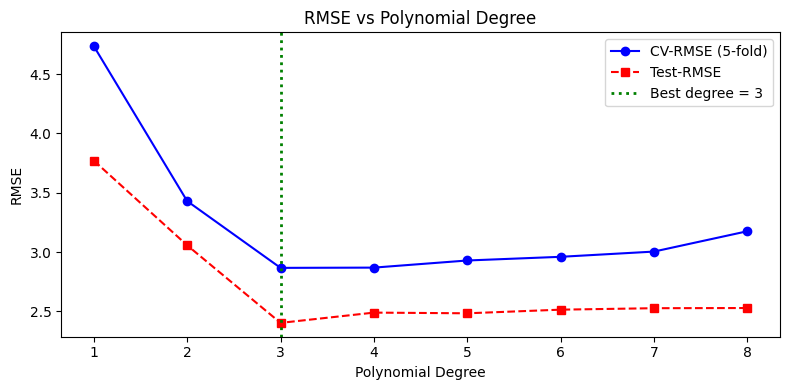

In [24]:
degrees = list(cv_rmse.keys())   # [1, 2, 3, 4, 5, 6, 7, 8] — used as x-axis values

plt.figure(figsize=(8, 4))       # width=8", height=4" — wider than default for readability

# "o-b"  → solid blue line + circle markers   (CV-RMSE)
# "s--r" → dashed red line  + square markers  (Test-RMSE)
# showing both curves lets you see overfitting:
#   if Test-RMSE rises while CV-RMSE stays low → model is memorising, not learning
plt.plot(degrees, [cv_rmse[d]   for d in degrees], "o-b",  label="CV-RMSE (5-fold)")
plt.plot(degrees, [test_rmse[d] for d in degrees], "s--r", label="Test-RMSE")

# vertical green dotted line — visual marker for the automatically selected best degree
plt.axvline(best_degree, color="green", linestyle=":", linewidth=2,
            label=f"Best degree = {best_degree}")

plt.xlabel("Polynomial Degree")   # x-axis: degree tried
plt.ylabel("RMSE")                # y-axis: error in same unit as y
plt.title("RMSE vs Polynomial Degree")
plt.legend()          # colour-coded key for the two curves + marker line
plt.tight_layout()    # auto-adjust padding so axis labels are never clipped
plt.show()


---
## Step 5 — Final Report

Summary of the best model found:

| Metric | Value |
|--------|-------|
| Best polynomial degree | printed below |
| CV-RMSE (validation) | printed below |
| RMSE (test set) | printed below |

> **RMSE interpretation:** an RMSE of `k` means predictions are off by roughly `k` units on average — in the **same unit as `y`**.  
> A lower RMSE always means a better model.


In [25]:
print("=" * 50)
print(f"  Best polynomial degree : {best_degree}")
print(f"  CV-RMSE  (validation)  : {best_cv_rmse:.4f}")   # :.4f → 4 decimal places
print(f"  RMSE     (test set)    : {best_test_rmse:.4f}")
print("=" * 50)

# ─────────────────────────────────────────────────────────────
#  RESULT  (fill in after running):
#  Best degree : ???
#  RMSE        : ???
# ─────────────────────────────────────────────────────────────


  Best polynomial degree : 3
  CV-RMSE  (validation)  : 2.8674
  RMSE     (test set)    : 2.4038


---
# Behind the Scenes — Gradient Descent (گرادیان کاهشی)

> وقتی `model.fit(X_train, y_train)` را صدا می‌زنیم، در پشت صحنه **گرادیان کاهشی** اجرا می‌شود.  
> این بخش نشان می‌دهد که دقیقاً چه اتفاقی می‌افتد — با کد از صفر.

---

## What is Gradient Descent?

**Gradient Descent (گرادیان کاهشی)** = an iterative algorithm that finds the weights `w` that minimise the loss function (MSE).

```
Goal: find w that minimises   Loss(w) = MSE = (1/n) · Σ (yᵢ − ŷᵢ)²
                                                          ↑
                                              ŷᵢ = w₀ + w₁·x + w₂·x² + …
```

### The core idea — walk downhill

Imagine the loss function as a bowl-shaped surface. The weights `w` are a point on that surface.  
Gradient descent asks: **"which direction is downhill?"** — then takes a small step in that direction.

```
  Loss
   │        *
   │       * *
   │      *   *
   │     *     *        ← loss surface (bowl shape for linear regression)
   │    *       *
   │   *    ↓   *
   │        w*          ← minimum (what fit() finds)
   └─────────────── w
```

### One update step

```
  gradient  =  ∂Loss/∂w  =  (-2/n) · Xᵀ · (y − Xw)      ← direction of steepest ASCENT
  new w     =  w  −  α · gradient                          ← step in opposite direction (descent)
```

| Symbol | Name | Meaning |
|--------|------|---------|
| `w` | weights / parameters | the numbers the model learns (w₀, w₁, w₂, …) |
| `α` (alpha) | **learning rate** | how big each step is. Too large → overshoots. Too small → slow. |
| `∂Loss/∂w` | **gradient** | slope of the loss surface at the current `w` |
| `Xᵀ` | transpose of feature matrix | mathematical operation needed to compute gradient |
| `n` | number of samples | used to average the gradient |

### Why does it work?

- If gradient > 0 → loss increases as w increases → move w **left** (subtract gradient)
- If gradient < 0 → loss decreases as w increases → move w **right** (subtract negative = add)
- At the minimum → gradient = 0 → no update → algorithm stops

### sklearn's LinearRegression vs Gradient Descent

| | `LinearRegression()` in sklearn | Gradient Descent |
|---|---|---|
| Method | **Closed-form** (Normal Equation): `w = (XᵀX)⁻¹ Xᵀy` | **Iterative** updates |
| Speed | One step, exact | Many iterations, approximate |
| When used | Small/medium datasets | Large datasets, neural networks |
| Result | Identical minimum | Same minimum (if converged) |

> sklearn's `LinearRegression` uses the **Normal Equation** — a direct mathematical formula that jumps straight to the minimum without iterating. Gradient Descent is shown here to reveal the underlying concept.


In [ ]:

# ═══════════════════════════════════════════════════════════════
#  GRADIENT DESCENT FROM SCRATCH
#  This code manually does what model.fit() does internally.
#  We use degree=2 (quadratic) to keep it simple and visible.
# ═══════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt

# ── Step 0: build polynomial features (degree=2) ────────────
# PolynomialFeatures(degree=2) turns [x] into [1, x, x²]
# We do this manually here so the math is visible
poly_manual = PolynomialFeatures(degree=2, include_bias=True)

# X_train has shape (n_train, 1) — one feature column
# after expansion → shape (n_train, 3): columns [1, x, x²]
X_poly = poly_manual.fit_transform(X_train)   # shape: (n_train, 3)

n, p = X_poly.shape   # n = number of training samples
                       # p = number of weights  (= degree + 1 = 3)

# ── Step 1: hyperparameters ──────────────────────────────────
alpha      = 0.001    # learning rate (α): size of each gradient step
                       #   too large  → weights explode (diverge)
                       #   too small  → takes too many steps (slow)
n_iter     = 5000     # number of gradient descent iterations
                       #   more iterations → closer to the true minimum

# ── Step 2: initialise weights ───────────────────────────────
# start with all weights = 0: [w₀=0, w₁=0, w₂=0]
# gradient descent will update these step by step
w = np.zeros(p)        # shape: (p,) = (3,)

# store loss at each iteration so we can plot the learning curve
loss_history = []      # list of MSE values, one per iteration

# ── Step 3: gradient descent loop ───────────────────────────
for iteration in range(n_iter):

    # --- FORWARD PASS: compute predictions with current weights ---
    # ŷ = X · w  (matrix multiplication)
    # X_poly shape: (n, p),  w shape: (p,)  →  y_hat shape: (n,)
    y_hat = X_poly @ w          # @ = matrix multiply;  ŷᵢ = w₀ + w₁·xᵢ + w₂·xᵢ²

    # --- LOSS: MSE = Mean Squared Error = (1/n) · Σ(yᵢ − ŷᵢ)² ---
    errors = y_train - y_hat    # residuals: how far off each prediction is, shape (n,)
    mse    = np.mean(errors**2) # average of squared residuals  (scalar)
    loss_history.append(mse)   # save for the learning curve plot

    # --- BACKWARD PASS: compute gradient of MSE with respect to w ---
    # gradient = ∂MSE/∂w = (-2/n) · Xᵀ · errors
    # Xᵀ shape: (p, n),  errors shape: (n,)  →  gradient shape: (p,)
    # meaning: how much does each weight wᵢ contribute to the total error?
    gradient = (-2 / n) * (X_poly.T @ errors)   # direction of steepest ASCENT in loss

    # --- UPDATE: move weights in the opposite direction of the gradient ---
    # w_new = w_old − α · gradient
    # subtracting gradient → moving DOWNHILL (toward lower loss)
    w = w - alpha * gradient    # update all weights simultaneously

# ── Step 4: final weights found by gradient descent ─────────
print("Weights found by Gradient Descent:")
for i, wi in enumerate(w):
    print(f"  w{i} = {wi:.6f}    (coefficient of x^{i})")

# compare with sklearn's exact solution
from sklearn.linear_model import LinearRegression
sklearn_model = LinearRegression(fit_intercept=False)  # bias already in X_poly column
sklearn_model.fit(X_poly, y_train)
print("\nWeights found by sklearn (Normal Equation — exact):")
for i, wi in enumerate(sklearn_model.coef_):
    print(f"  w{i} = {wi:.6f}    (coefficient of x^{i})")

# ── Step 5: plot the learning curve ─────────────────────────
# learning curve = how MSE decreases over iterations
# a healthy curve falls steeply then flattens → convergence
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# left plot: full learning curve
axes[0].plot(loss_history, color="steelblue", linewidth=1.5)
axes[0].set_xlabel("Iteration")                          # x-axis: iteration number
axes[0].set_ylabel("MSE (Mean Squared Error)")           # y-axis: loss value
axes[0].set_title("Learning Curve — Full")
axes[0].set_yscale("log")                                # log scale shows early drop clearly

# right plot: last 20% of iterations (zoom in on convergence zone)
start = int(0.8 * n_iter)                                # start at 80% of iterations
axes[1].plot(range(start, n_iter), loss_history[start:], color="darkorange", linewidth=1.5)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("MSE (Mean Squared Error)")
axes[1].set_title("Learning Curve — Convergence Zone (last 20%)")

plt.tight_layout()
plt.show()

# ── Step 6: visualise what the model learned ─────────────────
x_line  = np.linspace(X_train.min(), X_train.max(), 300).reshape(-1, 1)
X_line_poly = poly_manual.transform(x_line)   # expand to [1, x, x²]
y_line_gd   = X_line_poly @ w                 # predictions from gradient descent weights

plt.figure(figsize=(8, 4))
plt.scatter(X_train, y_train, s=15, alpha=0.6, label="Training data")
plt.plot(x_line, y_line_gd, color="red", linewidth=2,
         label=f"Gradient Descent fit (degree=2, {n_iter} iterations)")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Gradient Descent Result — Polynomial degree 2")
plt.legend()
plt.tight_layout()
plt.show()

final_rmse = np.sqrt(loss_history[-1])
print(f"\nFinal training RMSE (Root Mean Squared Error) after {n_iter} iterations: {final_rmse:.4f}")


---
# SGD Regression — Stochastic Gradient Descent

## GD vs SGD — what is the difference?

In the previous cell we implemented **Batch Gradient Descent (GD)**:  
every iteration uses **all n samples** to compute the gradient.

**SGD (Stochastic Gradient Descent)** uses only **1 random sample** per iteration.

```
Batch GD  (what we coded):
  iteration 1:  gradient = (-2/n) · Xᵀ · (y − Xw)   ← all n samples
  iteration 2:  same
  ...

SGD (Stochastic Gradient Descent):
  iteration 1:  pick random sample i₁  →  gradient from (xᵢ₁, yᵢ₁) only
  iteration 2:  pick random sample i₂  →  gradient from (xᵢ₂, yᵢ₂) only
  ...
```

### Three variants

| Name | Samples per update | Speed | Stability |
|------|--------------------|-------|-----------|
| **Batch GD** | all n | slow per epoch | very smooth |
| **SGD** | 1 random sample | fastest per update | noisy, jumpy |
| **Mini-batch GD** | small batch (e.g. 32) | middle ground | middle ground |

### Why use SGD if it is noisier?

- Works on **huge datasets** where loading all n samples into memory is impossible
- The noise can actually **escape local minima** (useful for neural networks)
- sklearn's `SGDRegressor` uses SGD internally — the same algorithm that trains deep learning models

### SGD update rule (one sample at a time)

```
pick random index i
ŷᵢ     =  w · xᵢ                     ← predict for ONE sample
errorᵢ =  yᵢ − ŷᵢ                    ← error for that one sample
gradient = -2 · xᵢ · errorᵢ          ← gradient from ONE sample (no 1/n average)
w_new  =  w − α · gradient            ← same update rule as batch GD
```

### Key parameters of `SGDRegressor`

| Parameter | Meaning | Default |
|-----------|---------|---------|
| `loss` | loss function to minimise | `"squared_error"` = MSE |
| `alpha` | **regularisation** strength (not learning rate here!) | `0.0001` |
| `eta0` | **initial learning rate** (α in the formula) | `0.01` |
| `learning_rate` | how η changes over iterations | `"invscaling"` |
| `max_iter` | maximum number of passes over data (epochs) | `1000` |
| `tol` | stop early if loss improvement < tol | `1e-3` |
| `random_state` | seed for reproducibility | `None` |

> **Note:** in `SGDRegressor`, `alpha` = regularisation (L2 penalty), NOT the learning rate.  
> The learning rate is controlled by `eta0` and `learning_rate`.


In [ ]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler   # SGD needs scaled features to converge properly

# ── Step 0: polynomial expansion (degree=2) ──────────────────
# same as before: [x] → [1, x, x²]
poly_sgd = PolynomialFeatures(degree=2, include_bias=False)
# include_bias=False because SGDRegressor adds its own intercept internally

X_train_poly = poly_sgd.fit_transform(X_train)   # shape: (n_train, 2)  columns: [x, x²]
X_test_poly  = poly_sgd.transform(X_test)         # shape: (n_test,  2)

# ── Step 1: feature scaling — REQUIRED for SGD ───────────────
# SGD is very sensitive to feature scale:
#   if x is in range [0, 1000] and x² in [0, 1e6], gradients are wildly different
#   StandardScaler transforms each column → mean=0, std=1
#   this makes all features equally sized → stable, faster convergence
scaler       = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)   # fit on train, transform train
X_test_scaled  = scaler.transform(X_test_poly)         # only transform test (no fit!)
# ^ IMPORTANT: we never fit the scaler on test data — that would be leaking

# ── Step 2: build SGDRegressor ────────────────────────────────
sgd_model = SGDRegressor(
    loss          = "squared_error",  # loss function: MSE (Mean Squared Error) = (1/n)·Σ(y−ŷ)²
    eta0          = 0.01,             # initial learning rate (α) — size of first gradient step
    learning_rate = "invscaling",     # η decreases over time: ηₜ = eta0 / t^power_t
                                      #   invscaling = "inverse scaling": slows down as it converges
    max_iter      = 2000,             # maximum number of full passes over training data (epochs)
                                      #   one epoch = the model has seen every sample once
    tol           = 1e-4,             # convergence tolerance: stop early if loss improvement < tol
    alpha         = 1e-4,             # L2 regularisation strength (NOT the learning rate)
                                      #   L2 adds penalty: loss += alpha · Σwᵢ²  → keeps weights small
    random_state  = 42                # fixed seed for reproducibility
)

# ── Step 3: fit (train) ───────────────────────────────────────
# internally: for each epoch, shuffle samples, then for each sample:
#   1. compute ŷᵢ = w · xᵢ
#   2. errorᵢ = yᵢ − ŷᵢ
#   3. gradient = -2 · xᵢ · errorᵢ
#   4. w = w − ηₜ · gradient   (ηₜ decreases over time)
sgd_model.fit(X_train_scaled, y_train)

# ── Step 4: predict and evaluate ─────────────────────────────
y_pred_sgd_train = sgd_model.predict(X_train_scaled)
y_pred_sgd_test  = sgd_model.predict(X_test_scaled)

rmse_train_sgd = np.sqrt(mean_squared_error(y_train, y_pred_sgd_train))
rmse_test_sgd  = np.sqrt(mean_squared_error(y_test,  y_pred_sgd_test))
r2_sgd         = r2_score(y_test, y_pred_sgd_test)
# R² (R-squared / Coefficient of Determination):
#   1.0 → perfect fit
#   0.0 → no better than predicting the mean of y
#   < 0 → worse than predicting the mean

print("─" * 50)
print("  SGDRegressor Results (degree=2)")
print("─" * 50)
print(f"  Intercept  (w₀)                : {sgd_model.intercept_[0]:.4f}")
print(f"  Coef x     (w₁)                : {sgd_model.coef_[0]:.4f}")
print(f"  Coef x²    (w₂)                : {sgd_model.coef_[1]:.4f}")
print(f"  Train RMSE (Root MSE on train) : {rmse_train_sgd:.4f}")
print(f"  Test  RMSE (Root MSE on test)  : {rmse_test_sgd:.4f}")
print(f"  R²    (Coefficient of Det.)    : {r2_sgd:.4f}")
print(f"  Epochs run                     : {sgd_model.n_iter_}")
# n_iter_ = actual number of epochs before convergence or max_iter reached
print("─" * 50)

# ── Step 5: compare all three methods ────────────────────────
# Normal Equation (sklearn LinearRegression) — exact, one step
from sklearn.linear_model import LinearRegression
normal_eq = Pipeline([
    ("poly",   PolynomialFeatures(degree=2, include_bias=True)),
    ("linreg", LinearRegression())
])
normal_eq.fit(X_train, y_train)
rmse_normal = np.sqrt(mean_squared_error(y_test, normal_eq.predict(X_test)))

# Batch GD — from the previous cell (already computed)
rmse_batch_gd = np.sqrt(loss_history[-1])   # training RMSE from batch GD loop

print("\nComparison of all three methods (degree=2, test RMSE):")
print(f"  Normal Equation  (sklearn)  : {rmse_normal:.4f}   ← exact, one-shot")
print(f"  Batch GD         (manual)   : {rmse_batch_gd:.4f}   ← all samples per iter (train RMSE)")
print(f"  SGD              (sklearn)  : {rmse_test_sgd:.4f}   ← one sample per iter")

# ── Step 6: plot fit ─────────────────────────────────────────
x_line       = np.linspace(X_train.min(), X_train.max(), 300).reshape(-1, 1)
x_line_poly  = poly_sgd.transform(x_line)
x_line_scaled = scaler.transform(x_line_poly)
y_line_sgd   = sgd_model.predict(x_line_scaled)
y_line_normal = normal_eq.predict(x_line)

plt.figure(figsize=(9, 4))
plt.scatter(X_train, y_train, s=15, alpha=0.5, label="Training data")
plt.plot(x_line, y_line_normal, "b-",  linewidth=2, label="Normal Equation (exact)")
plt.plot(x_line, y_line_sgd,    "r--", linewidth=2, label="SGDRegressor")
plt.xlabel("X")
plt.ylabel("y")
plt.title("SGD vs Normal Equation — Polynomial degree 2")
plt.legend()
plt.tight_layout()
plt.show()


---
# LinearRegression vs SGDRegressor — Full Comparison

---

## 1. Internal Algorithm — How Do They Learn?

| | `LinearRegression` | `SGDRegressor` |
|---|---|---|
| **Method** | Normal Equation | Stochastic Gradient Descent |
| **Formula** | `w = (XᵀX)⁻¹ Xᵀy` | `w = w − η · gradient` (repeated) |
| **Steps** | **One step** — jumps directly to the answer | **Thousands of iterations** — step by step |
| **Answer** | **Exact** | **Approximate** |

```
LinearRegression:
  fit()  →  w = (XᵀX)⁻¹ Xᵀy        ← one matrix multiplication, done

SGDRegressor:
  fit()  →  for each epoch:
              shuffle data
              for each sample i:
                ŷᵢ = w · xᵢ
                w  = w − η · (-2·xᵢ·(yᵢ−ŷᵢ))   ← thousands of weight updates
```

---

## 2. When to Use Which?

| Situation | Use |
|-----------|-----|
| Small / medium dataset (n < 100,000) | `LinearRegression` |
| Very large dataset (n > 100,000) | `SGDRegressor` |
| Exact answer required | `LinearRegression` |
| Limited memory (cannot load all data at once) | `SGDRegressor` |
| Online / real-time learning | `SGDRegressor` |
| Built-in regularisation needed | `SGDRegressor` |

---

## 3. Input Parameters (before `fit`)

### `LinearRegression` — Parameters

| Parameter | Type | Default | Meaning |
|-----------|------|---------|---------|
| `fit_intercept` | bool | `True` | Whether to learn the intercept term w₀ |
| `copy_X` | bool | `True` | Copy X before fitting so it is not modified in place |
| `n_jobs` | int | `None` | Number of CPU cores to use for computation |
| `positive` | bool | `False` | Force all learned coefficients to be positive |

### `SGDRegressor` — Parameters

| Parameter | Default | Meaning |
|-----------|---------|---------|
| `loss` | `"squared_error"` | Loss function: `squared_error` = MSE, `huber` = robust to outliers |
| `eta0` | `0.01` | **Initial learning rate** — size of the first gradient step |
| `learning_rate` | `"invscaling"` | How η changes over time: `constant`, `invscaling`, `adaptive` |
| `max_iter` | `1000` | Maximum number of epochs (one epoch = one full pass over training data) |
| `tol` | `1e-3` | Stop early if loss improvement falls below this threshold |
| `alpha` | `1e-4` | **L2 regularisation strength** — NOT the learning rate |
| `penalty` | `"l2"` | Type of regularisation: `l1`, `l2`, `elasticnet` |
| `shuffle` | `True` | Whether to shuffle the data at the start of each epoch |
| `random_state` | `None` | Random seed for reproducibility |
| `warm_start` | `False` | If `True`, reuse weights from the previous `fit()` call (online learning) |

---

## 4. Attributes After `fit()` — What Can You Access?

### `LinearRegression` after `fit`

| Attribute | Shape | Content |
|-----------|-------|---------|
| `.coef_` | `(p,)` | Learned coefficients `[w₁, w₂, …, wₚ]` |
| `.intercept_` | scalar | Intercept term `w₀` — a plain number |
| `.rank_` | int | Rank of matrix X — used to detect multicollinearity |
| `.singular_` | `(p,)` | Singular values of X — very small values indicate near-singular matrix |
| `.n_features_in_` | int | Number of features seen during `fit` |
| `.feature_names_in_` | array | Feature names (only available if a DataFrame was passed) |

### `SGDRegressor` after `fit`

| Attribute | Shape | Content |
|-----------|-------|---------|
| `.coef_` | `(p,)` | Learned coefficients `[w₁, w₂, …, wₚ]` |
| `.intercept_` | `(1,)` | Intercept term w₀ — **a one-element array, not a scalar** |
| `.n_iter_` | int | Actual number of epochs run until convergence |
| `.t_` | int | Total number of weight updates = `n_iter_` × `n_samples` |
| `.loss_function_` | object | Internal loss function object used during training |
| `.n_features_in_` | int | Number of features seen during `fit` |

---

## 5. Key Difference — `.intercept_` Type

```python
# LinearRegression → plain scalar
lr_model.intercept_          # 2.5

# SGDRegressor → one-element array
sgd_model.intercept_         # array([2.5])
sgd_model.intercept_[0]      # 2.5   ← must index with [0] to get a number
```

---

## 6. Key Difference — Exclusive Attributes

```python
# Only in LinearRegression (not available in SGDRegressor):
lr_model.rank_               # rank of feature matrix X
lr_model.singular_           # singular values — detect near-collinear features

# Only in SGDRegressor (not available in LinearRegression):
sgd_model.n_iter_            # how many epochs were actually needed
sgd_model.t_                 # total individual weight update steps
sgd_model.loss_function_     # the internal loss object
```


In [ ]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# ── Fit both models on the same data ─────────────────────────

# --- LinearRegression ---
poly_lr = PolynomialFeatures(degree=2, include_bias=True)
X_tr_lr = poly_lr.fit_transform(X_train)   # expands [x] → [1, x, x²]
X_te_lr = poly_lr.transform(X_test)

lr_model = LinearRegression(
    fit_intercept = True,    # learn the intercept term w₀
    copy_X        = True,    # copy X so the original array is not modified
    n_jobs        = None,    # use one CPU core (None = default)
    positive      = False    # coefficients can be negative
)
lr_model.fit(X_tr_lr, y_train)

# --- SGDRegressor ---
poly_sgd2 = PolynomialFeatures(degree=2, include_bias=False)
X_tr_sgd2 = poly_sgd2.fit_transform(X_train)   # expands [x] → [x, x²]
X_te_sgd2 = poly_sgd2.transform(X_test)

# SGD requires scaled features — without scaling, gradients for x and x²
# have very different magnitudes and training becomes unstable
scaler2        = StandardScaler()                    # transforms each column → mean=0, std=1
X_tr_sgd2_sc   = scaler2.fit_transform(X_tr_sgd2)   # fit on train, then transform
X_te_sgd2_sc   = scaler2.transform(X_te_sgd2)        # transform test only — no fit (avoids leaking)

sgd_model2 = SGDRegressor(
    loss          = "squared_error",  # loss = MSE = (1/n) · Σ(y − ŷ)²
    eta0          = 0.01,             # initial learning rate η₀ (size of first step)
    learning_rate = "invscaling",     # ηₜ = eta0 / t^0.25  — decreases over time
    max_iter      = 2000,             # maximum number of epochs
                                      # one epoch = model has seen every training sample once
    tol           = 1e-4,             # stop early if loss improvement < tol between epochs
    alpha         = 1e-4,             # L2 regularisation strength — adds α·Σwᵢ² to loss
                                      # keeps weights small, reduces overfitting
    penalty       = "l2",             # regularisation type: l1 (sparse), l2 (smooth), elasticnet
    shuffle       = True,             # shuffle samples at the start of each epoch
    random_state  = 42,               # fixed seed → same result every run
    warm_start    = False             # start from zero weights each time fit() is called
)
sgd_model2.fit(X_tr_sgd2_sc, y_train)

# ════════════════════════════════════════════════════════════
#  ATTRIBUTES AFTER fit() — what information is accessible?
# ════════════════════════════════════════════════════════════

print("━" * 55)
print("  LinearRegression — attributes after fit()")
print("━" * 55)

# .coef_: learned weights for each feature column
# shape (p,) where p = number of features including bias if fit_intercept=False
print(f"\n.coef_           shape {lr_model.coef_.shape} — learned feature weights:")
for i, c in enumerate(lr_model.coef_):
    print(f"   w{i} = {c:+.4f}   coefficient of x^{i}")

# .intercept_: the bias / intercept term w₀
# in LinearRegression this is a plain scalar (single number)
print(f"\n.intercept_      (plain scalar — intercept w₀):")
print(f"   {lr_model.intercept_:.4f}")

# .rank_: rank of the feature matrix X
# if rank < number of features → some features are linearly dependent (multicollinearity)
print(f"\n.rank_           (rank of feature matrix X — detects multicollinearity):")
print(f"   {lr_model.rank_}")

# .singular_: singular values of X
# a very small value (≈ 0) means the matrix is nearly singular → numerical instability
print(f"\n.singular_       (singular values of X):")
print(f"   {lr_model.singular_.round(3)}")

# .n_features_in_: number of input features the model saw during fit
print(f"\n.n_features_in_  (number of features seen at fit time):")
print(f"   {lr_model.n_features_in_}")

print("\n" + "━" * 55)
print("  SGDRegressor — attributes after fit()")
print("━" * 55)

# .coef_: same as LinearRegression — learned weights per feature
print(f"\n.coef_           shape {sgd_model2.coef_.shape} — learned feature weights:")
for i, c in enumerate(sgd_model2.coef_):
    print(f"   w{i+1} = {c:+.4f}   coefficient of feature {i+1}")

# .intercept_: KEY DIFFERENCE — SGDRegressor returns a one-element ARRAY, not a scalar
# must use [0] to extract the number
print(f"\n.intercept_      (one-element array — NOT a scalar):")
print(f"   {sgd_model2.intercept_}   →   use [0]: {sgd_model2.intercept_[0]:.4f}")

# .n_iter_: how many epochs were actually run (may be less than max_iter if tol triggered)
print(f"\n.n_iter_         (actual epochs run until convergence):")
print(f"   {sgd_model2.n_iter_}   (max_iter was set to {sgd_model2.max_iter})")

# .t_: total number of individual weight update steps
# = n_iter_ × n_samples  (one update per sample per epoch)
print(f"\n.t_              (total individual weight updates):")
print(f"   {sgd_model2.t_}  =  n_iter_ {sgd_model2.n_iter_}  ×  n_samples {len(X_train)}")

print(f"\n.n_features_in_  (number of features seen at fit time):")
print(f"   {sgd_model2.n_features_in_}")

# ── Final prediction comparison ───────────────────────────────
y_pred_lr  = lr_model.predict(X_te_lr)
y_pred_sgd = sgd_model2.predict(X_te_sgd2_sc)

rmse_lr  = np.sqrt(mean_squared_error(y_test, y_pred_lr))
rmse_sgd = np.sqrt(mean_squared_error(y_test, y_pred_sgd))

print("\n" + "━" * 55)
print("  Final comparison on test set (degree=2)")
print("━" * 55)
print(f"  LinearRegression  Test-RMSE : {rmse_lr:.4f}   (exact solution)")
print(f"  SGDRegressor      Test-RMSE : {rmse_sgd:.4f}   (approximate solution)")
print(f"  Difference in RMSE          : {abs(rmse_lr - rmse_sgd):.4f}")
print("━" * 55)
